# Chapter 20 — Low-Power Wide-Area Networks (LPWAN): Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 20.1 | LoRaWAN link budget and coverage | Hata (Okumura-Hata) path loss + log-normal shadowing, coverage probability |
| 20.2 | Spreading-factor trade-off | LoRa time-on-air model, data-rate vs. range vs. capacity |
| 20.3 | LoRaWAN vs. Sigfox network capacity | Duty-cycle traffic and energy simulation, battery-life estimate |
| 20.4 | Message reliability via frequency diversity | Monte Carlo validation of Sigfox's triple-transmission strategy |

---
## Setup

The cell below defines the shared physical-layer "toolkit" used throughout
this notebook: a LoRaWAN link-budget/coverage model (Exercises 20.1–20.2) and
the official Semtech LoRa data-rate and time-on-air formulas (Exercises
20.2–20.3). Sensitivity values are taken directly from the Semtech
SX1276/77/78/79 datasheet (Rev. 7, May 2020, Table 10, 125 kHz bandwidth,
Band 1).

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.6,
})

# Semtech SX1276/77/78/79 datasheet (Rev. 7, May 2020), Table 10:
# LoRa receiver sensitivity, 125 kHz bandwidth, Band 1 (868/915 MHz),
# highest LNA gain, split Rx/Tx path (RFS_L125_HF).
SENSITIVITY_DBM = {7: -123, 8: -126, 9: -129, 10: -132, 11: -133, 12: -136}


class LoRaWANLinkBudget:
    '''Hata (Okumura-Hata) empirical macrocell path-loss model with
    environment-dependent log-normal shadowing, used for LoRaWAN coverage
    planning. Reference: Hata, M. (1980), IEEE Trans. Vehicular Technology.
    '''

    def __init__(self, freq_hz=868e6, tx_power_dbm=14, h_b_m=30, h_m_m=1.5):
        self.freq_hz = freq_hz
        self.tx_power = tx_power_dbm
        self.h_b = h_b_m
        self.h_m = h_m_m
        # Environment-dependent shadowing standard deviation: more obstacles
        # and multipath in built-up areas widen the shadowing distribution.
        self.shadow_sigma = {'urban': 8.0, 'suburban': 6.0, 'rural': 4.0}
        self.sensitivity = SENSITIVITY_DBM

    def _urban_path_loss(self, distance_km):
        f_mhz = self.freq_hz / 1e6
        a_hm = (1.1*np.log10(f_mhz) - 0.7)*self.h_m - (1.56*np.log10(f_mhz) - 0.8)
        return (69.55 + 26.16*np.log10(f_mhz) - 13.82*np.log10(self.h_b) - a_hm
                + (44.9 - 6.55*np.log10(self.h_b)) * np.log10(distance_km))

    def _env_correction(self, environment):
        # Full Hata suburban/open-area additive corrections at fixed
        # frequency; the distance slope (the log10(d) coefficient) is
        # inherited unchanged from the urban baseline -- only the constant
        # offset differs by environment. See Exercise 20.1 Background.
        f_mhz = self.freq_hz / 1e6
        if environment == 'urban':
            return 0.0
        elif environment == 'suburban':
            return -(2*(np.log10(f_mhz/28))**2 + 5.4)
        elif environment == 'rural':
            return -(4.78*(np.log10(f_mhz))**2 - 18.33*np.log10(f_mhz) + 40.94)
        raise ValueError(environment)

    def mean_path_loss(self, distance_km, environment):
        return self._urban_path_loss(distance_km) + self._env_correction(environment)

    def link_margin(self, distance_km, environment, sf=7, shadowing=True, rng=None):
        pl = self.mean_path_loss(distance_km, environment)
        if shadowing:
            rng = rng if rng is not None else np.random
            pl = pl + rng.normal(0, self.shadow_sigma[environment], size=np.shape(distance_km))
        return (self.tx_power - pl) - self.sensitivity[sf]

    def coverage_probability(self, distance_km, environment, sf=7):
        '''P(link margin > 0) under log-normal shadowing (Rappaport, 2002).'''
        pl_mean = self.mean_path_loss(distance_km, environment)
        max_allowed_loss = self.tx_power - self.sensitivity[sf]
        z = (max_allowed_loss - pl_mean) / self.shadow_sigma[environment]
        return norm.cdf(z)

    def range_at_coverage(self, environment, sf=7, target_p=0.5, d_max=40, n=8000):
        d = np.linspace(0.05, d_max, n)
        p = self.coverage_probability(d, environment, sf)
        below = d[p >= target_p]
        return below[-1] if len(below) else 0.0


def lora_data_rate_bps(sf, bw_hz=125000, cr=1):
    '''LoRa PHY bit rate (Semtech datasheet Sec. 4.1.1.5). Matches the
    official table exactly, e.g. SF12/BW125/CR4-5 -> 293 bps.'''
    return sf * (4 / (4 + cr)) * bw_hz / (2 ** sf)


def lora_time_on_air(payload_bytes, sf, bw_hz=125000, cr=1, preamble_symbols=8,
                      header_enabled=True, crc_enabled=True, low_dr_optimize=None):
    '''Semtech datasheet Sec. 4.1.1.7 time-on-air model for a LoRa packet.'''
    de = (1 if (low_dr_optimize is None and bw_hz == 125000 and sf >= 11)
          else int(bool(low_dr_optimize)))
    t_sym = (2 ** sf) / bw_hz
    t_preamble = (preamble_symbols + 4.25) * t_sym
    ih = 0 if header_enabled else 1
    numerator = 8*payload_bytes - 4*sf + 28 + 16*int(crc_enabled) - 20*ih
    denom = 4 * (sf - 2*de)
    n_payload = 8 + max(math.ceil(numerator/denom) * (cr + 4), 0)
    return t_preamble + n_payload * t_sym


# Sigfox uplink parameters (EU RC1), per Sigfox technical documentation
# (build.sigfox.com/study and the Sigfox radio-interface specification):
SIGFOX_TOA_SINGLE_S = 2.0          # one packet at 100 bps, <=12-byte payload
SIGFOX_REPEATS = 3                  # mandatory frequency-diversity repetitions
SIGFOX_MAX_UPLINK_PER_DAY = 140     # regulatory/network quota, EU RC1
SIGFOX_MAX_DOWNLINK_PER_DAY = 4

print("Environment ready.")

Environment ready.


---
## Exercise 20.1 — LoRaWAN Link Budget and Coverage Analysis

### Background

A LoRaWAN gateway's coverage is usually quoted as a single number — "5 km in
the city, 15 km in the countryside" — but that single number hides an
important statistical fact: radio signals do not fade smoothly with
distance. Buildings, trees, and terrain cause random *shadowing* on top of
the average path loss, so two devices at the same distance from the gateway
can experience link margins that differ by 10 dB or more. This exercise
builds a coverage model that accounts for this randomness explicitly,
distinguishing between the *nominal* range (where the **average** path loss
crosses the maximum allowed value) and a much more conservative
**coverage-probability** range (the distance at which, say, 90% of devices
still close the link).

We model the average path loss with the Hata (Okumura-Hata) empirical formula —
originally developed for cellular macrocells, but still a reasonable
starting point at 868 MHz because it explicitly separates a base-station
height term from an environment-dependent correction. At a fixed frequency,
the suburban and open-area corrections below are environment-specific
empirical **loss offsets** added to the urban baseline — the log-distance
slope itself is inherited unchanged from the urban term:

$$
L_{\text{urban}}(d) = 69.55 + 26.16\log_{10} f - 13.82\log_{10} h_b - a(h_m)
                       + \bigl(44.9 - 6.55\log_{10} h_b\bigr)\log_{10} d
$$

$$
L_{\text{suburban}} = L_{\text{urban}} - 2\Bigl[\log_{10}\tfrac{f}{28}\Bigr]^2 - 5.4
\qquad\qquad
L_{\text{rural}} = L_{\text{urban}} - 4.78(\log_{10} f)^2 + 18.33\log_{10} f - 40.94
$$

where $f$ is in MHz, $h_b$ is the gateway antenna height (m), and $d$ is the
distance (km). A model with genuinely different path-loss *exponents* per
environment (lower in open terrain) would separate urban and rural ranges
even further — that's Challenge Task 2 below.

On top of this mean path loss we add environment-dependent log-normal
shadowing $\mathcal{N}(0, \sigma^2)$, with $\sigma$ larger in built-up
areas (more multipath and blockage) than in open terrain.

> **Model parameters.** Carrier frequency 868 MHz · transmit power 14 dBm
> (Semtech SX1276 RFO pin) · gateway height 30 m · device height 1.5 m ·
> bandwidth 125 kHz · shadowing σ = 8/6/4 dB (urban/suburban/rural) ·
> sensitivity at SF7 = −123 dBm (Semtech datasheet, Table 10).

### Coverage probability

For a link with mean path loss $\bar L(d)$ and shadowing standard
deviation $\sigma$, the probability that a randomly placed device at
distance $d$ still closes the link (margin $> 0$) is a direct application of
the Gaussian Q-function to the log-normal shadowing model (Rappaport,
*Wireless Communications*, 2002, Ch. 4):

$$
P_{\text{cov}}(d) = \Phi\!\left(\frac{L_{\max} - \bar L(d)}{\sigma}\right),
\qquad L_{\max} = P_{tx} - S(\mathrm{SF})
$$

where $\Phi$ is the standard normal CDF and $S(\mathrm{SF})$ is the
receiver sensitivity for the chosen spreading factor.

In [2]:
# ── Exercise 20.1: LoRaWAN link budget and coverage ───────────────────
lb = LoRaWANLinkBudget()                      # 868 MHz, 14 dBm, 30 m gateway
envs = ['urban', 'suburban', 'rural']
colors = {'urban': 'tab:red', 'suburban': 'tab:orange', 'rural': 'tab:green'}

print("Environment corrections relative to the urban baseline (additive offsets,")
print("NOT a change in path-loss exponent -- see Background above):")
for env in envs:
    print(f"  {env:10s}: {lb._env_correction(env):7.2f} dB   "
          f"(shadowing sigma = {lb.shadow_sigma[env]:.1f} dB)")

Environment corrections relative to the urban baseline (additive offsets,
NOT a change in path-loss exponent -- see Background above):
  urban     :    0.00 dB   (shadowing sigma = 8.0 dB)
  suburban  :   -9.85 dB   (shadowing sigma = 6.0 dB)
  rural     :  -28.35 dB   (shadowing sigma = 4.0 dB)


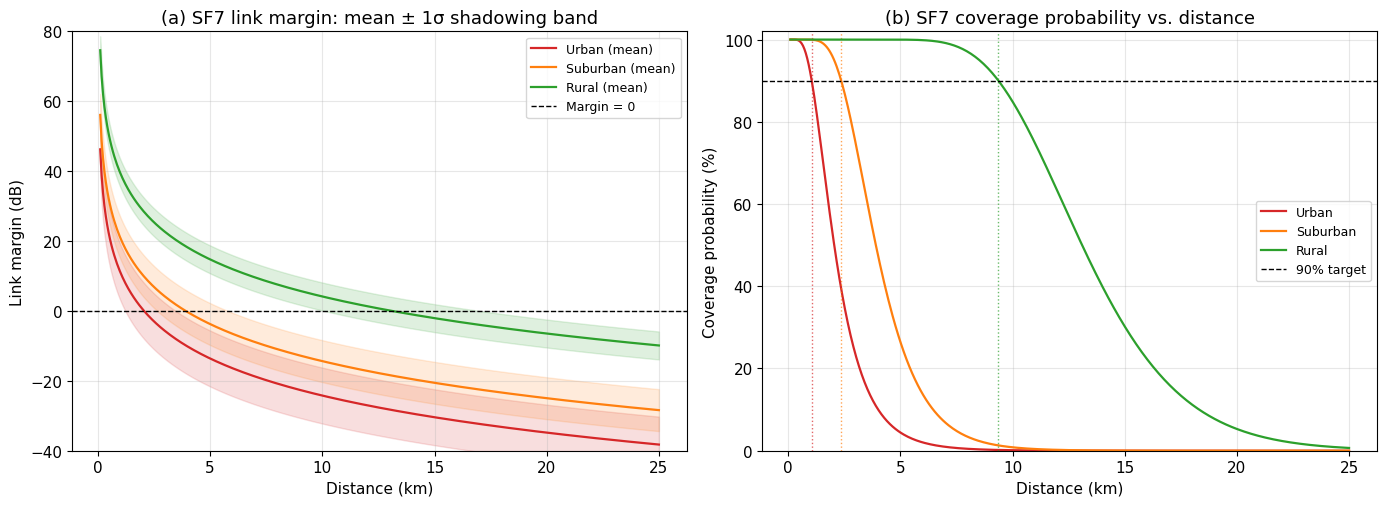

In [3]:
# ── Figure 20.1: Link margin and coverage probability, SF7 ────────────
d = np.linspace(0.1, 25, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
for env in envs:
    margin_mean = lb.link_margin(d, env, sf=7, shadowing=False)
    sigma = lb.shadow_sigma[env]
    ax.plot(d, margin_mean, color=colors[env], label=f'{env.capitalize()} (mean)')
    ax.fill_between(d, margin_mean - sigma, margin_mean + sigma, color=colors[env], alpha=0.15)
ax.axhline(0, color='k', ls='--', lw=1, label='Margin = 0')
ax.set_xlabel('Distance (km)'); ax.set_ylabel('Link margin (dB)')
ax.set_title('(a) SF7 link margin: mean ± 1σ shadowing band')
ax.legend(fontsize=9); ax.set_ylim(-40, 80)

ax = axes[1]
for env in envs:
    p = lb.coverage_probability(d, env, sf=7)
    ax.plot(d, p*100, color=colors[env], label=env.capitalize())
    r90 = lb.range_at_coverage(env, sf=7, target_p=0.90)
    ax.axvline(r90, color=colors[env], ls=':', lw=1, alpha=0.7)
ax.axhline(90, color='k', ls='--', lw=1, label='90% target')
ax.set_xlabel('Distance (km)'); ax.set_ylabel('Coverage probability (%)')
ax.set_title('(b) SF7 coverage probability vs. distance')
ax.legend(fontsize=9); ax.set_ylim(0, 102)

plt.tight_layout()
plt.show()

In [4]:
# ── Exercise 20.1 output: nominal vs. coverage-probability range, SF7 ─
print(f"{'Environment':<10s} {'shadow sigma(dB)':>16s} {'nominal(50%) km':>16s} {'90%-coverage km':>16s}")
for env in envs:
    r50 = lb.range_at_coverage(env, sf=7, target_p=0.50)
    r90 = lb.range_at_coverage(env, sf=7, target_p=0.90)
    print(f"{env:<10s} {lb.shadow_sigma[env]:16.1f} {r50:16.2f} {r90:16.2f}")

Environment shadow sigma(dB)  nominal(50%) km  90%-coverage km
urban                   8.0             2.05             1.05
suburban                6.0             3.91             2.36
rural                   4.0            13.10             9.37


In [5]:
# ── Monte Carlo validation of the analytic coverage formula ───────────
rng = np.random.default_rng(7)
trials = 20000
margins = lb.link_margin(np.full(trials, 10.0), 'rural', sf=7, shadowing=True, rng=rng)
empirical_p = np.mean(margins > 0)
analytic_p = lb.coverage_probability(10.0, 'rural', sf=7)
print(f"Rural, SF7, d = 10 km, {trials} Monte Carlo trials:")
print(f"  empirical P(coverage) = {empirical_p:.4f}")
print(f"  analytic  P(coverage) = {analytic_p:.4f}")

Rural, SF7, d = 10 km, 20000 Monte Carlo trials:
  empirical P(coverage) = 0.8521
  analytic  P(coverage) = 0.8493


### Analysis

**Figure 20.1(a)** shows the mean link margin for all three environments at
SF7, with a shaded band representing $\pm 1\sigma$ of shadowing. The urban
and suburban curves cross zero margin within a few kilometres, while the
rural curve, carrying the much larger open-area offset, stays positive out
to roughly 13 km on average — the corrected model's environment
*separation* at work, not a change in how quickly the curves fall off with
distance (all three have the same slope by construction; see the Background
discussion above).

**Figure 20.1(b)** and the table above make the practical consequence of
shadowing explicit. The *nominal* range overstates real-world coverage,
because at that exact distance, by construction, only half of the devices
actually close the link — shadowing pushes the rest below threshold. A
network planner who provisions gateways using the nominal range will find
that a substantial fraction of end devices at the cell edge experience
intermittent connectivity. The 90%-coverage radius is far more conservative:
1.05 km (urban), 2.36 km (suburban), and 9.37 km (rural) at SF7 — roughly
half the nominal figure in each environment, because urban and suburban
shadowing (8 and 6 dB) is wider than rural shadowing (4 dB).

The Monte Carlo validation confirms that the closed-form Gaussian-Q
expression for coverage probability matches a direct random simulation of
20,000 shadowed links to within a fraction of a percentage point.

> **Key takeaway.** A single "range" number for a wireless link is
> ambiguous unless it states the coverage probability it corresponds to.
> The nominal (mean-path-loss) range is an optimistic upper bound; a
> 90%-coverage design rule — standard practice in cellular network
> planning — typically halves that figure once realistic shadowing is
> taken into account.

### Challenge tasks

1. Repeat the analysis for SF12 and compare the 90%-coverage radius to the
   SF7 result. By what factor does range improve, and is that factor
   consistent across all three environments?
2. Replace the single inherited path-loss slope with a genuine
   log-distance model $L(d) = L_0 + 10\,n\log_{10}d$ using a *different
   exponent* $n$ per environment (e.g. $n_{\text{urban}}\approx3.5$,
   $n_{\text{rural}}\approx2.3$). How much further does rural range extend
   once the exponent itself, not just the offset, changes with environment?
3. The gateway antenna height $h_b$ was fixed at 30 m. Sweep $h_b$ from
   10 m to 50 m and plot how the 90%-coverage radius changes in the rural
   environment. At what height do diminishing returns set in?
4. Determine, for the urban environment, the transmit power increase
   needed to achieve a 95%-coverage radius equal to the *nominal* (50%)
   range computed in this exercise.

---
## Exercise 20.2 — Spreading Factor and the Range–Data-Rate Trade-off

### Background

Exercise 20.1 showed that a higher spreading factor (lower sensitivity
threshold) buys longer range. But that range is not free: LoRa's chirp
spread-spectrum modulation represents each bit with $2^{\mathrm{SF}}$ chips,
so the symbol rate — and therefore the data rate — falls geometrically as
SF increases. The PHY bit rate is (Semtech datasheet, Sec. 4.1.1.5):

$$
R_b(\mathrm{SF}) = \mathrm{SF} \cdot \frac{4}{4+\mathrm{CR}} \cdot \frac{BW}{2^{\mathrm{SF}}}
$$

and the time-on-air of a packet — preamble plus payload — follows the
Semtech AN1200.13 / datasheet Sec. 4.1.1.7 formula implemented in the Setup
cell. Because European 868 MHz regulations cap the duty cycle at 1% per
sub-band (a device may transmit for at most 36 s per hour), a shorter
time-on-air directly translates into a higher *ceiling* on the number of
messages a device may legally send per day. This is precisely the trade-off
that **Adaptive Data Rate (ADR)** is designed to manage.

> **Model parameters.** Payload 20 bytes · bandwidth 125 kHz · coding rate
> 4/5 (cr=1) · SF swept 7–12 · EU duty cycle 1%/hour (36 s).

In [6]:
# ── Exercise 20.2: spreading-factor trade-off ──────────────────────────
sfs = list(range(7, 13))
payload = 20  # bytes -- a representative smart-meter / sensor reading

dr      = [lora_data_rate_bps(sf) for sf in sfs]
toa     = [lora_time_on_air(payload, sf) for sf in sfs]
max_day = [(3600*0.01/t)*24 for t in toa]              # 1% EU duty cycle

r90_urban  = [lb.range_at_coverage('urban',    sf=sf, target_p=0.90) for sf in sfs]
r90_suburb = [lb.range_at_coverage('suburban', sf=sf, target_p=0.90) for sf in sfs]
r90_rural  = [lb.range_at_coverage('rural',    sf=sf, target_p=0.90) for sf in sfs]

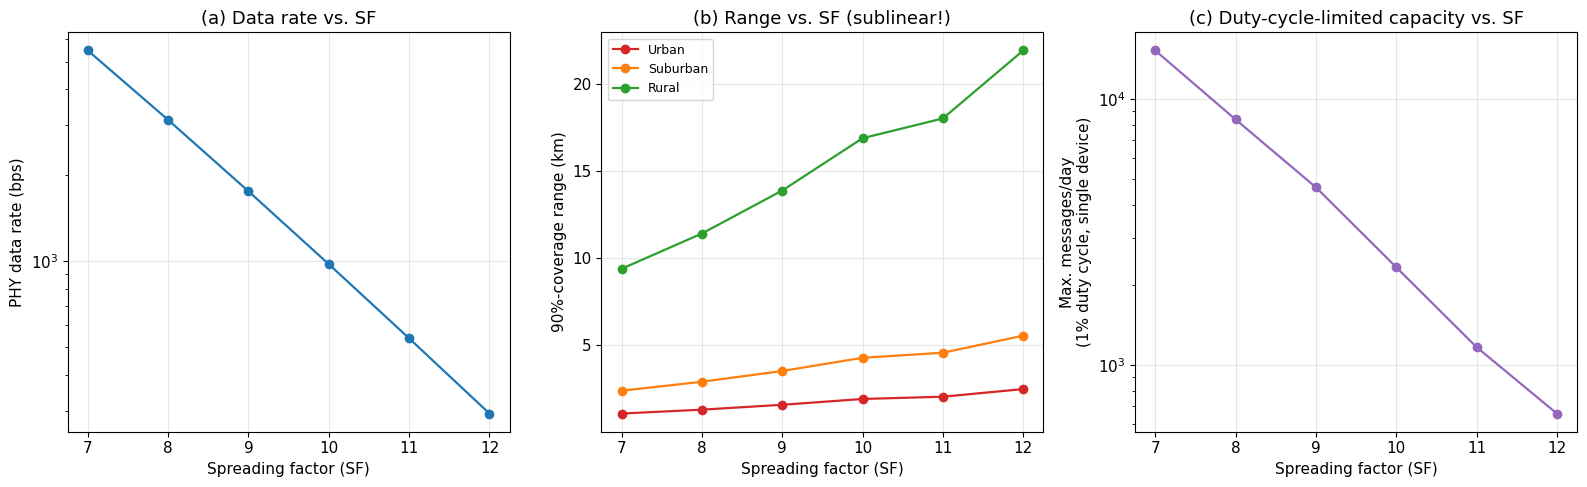

In [7]:
# ── Figure 20.2: data rate, range, and capacity vs. SF ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.semilogy(sfs, dr, 'o-', color='tab:blue')
ax.set_xlabel('Spreading factor (SF)'); ax.set_ylabel('PHY data rate (bps)')
ax.set_title('(a) Data rate vs. SF'); ax.set_xticks(sfs)

ax = axes[1]
ax.plot(sfs, r90_urban, 'o-', color='tab:red', label='Urban')
ax.plot(sfs, r90_suburb, 'o-', color='tab:orange', label='Suburban')
ax.plot(sfs, r90_rural, 'o-', color='tab:green', label='Rural')
ax.set_xlabel('Spreading factor (SF)'); ax.set_ylabel('90%-coverage range (km)')
ax.set_title('(b) Range vs. SF (sublinear!)'); ax.set_xticks(sfs); ax.legend(fontsize=9)

ax = axes[2]
ax.semilogy(sfs, max_day, 'o-', color='tab:purple')
ax.set_xlabel('Spreading factor (SF)')
ax.set_ylabel('Max. messages/day\n(1% duty cycle, single device)')
ax.set_title('(c) Duty-cycle-limited capacity vs. SF'); ax.set_xticks(sfs)

plt.tight_layout()
plt.show()

In [8]:
# ── Exercise 20.2 output: SF trade-off summary (20-byte payload) ──────
print(f"{'SF':>3s} {'DR(bps)':>9s} {'ToA(ms)':>9s} {'msgs/day':>9s} "
      f"{'urban90(km)':>12s} {'suburb90(km)':>13s} {'rural90(km)':>12s}")
for i, sf in enumerate(sfs):
    print(f"{sf:3d} {dr[i]:9.1f} {toa[i]*1000:9.1f} {max_day[i]:9.0f} "
          f"{r90_urban[i]:12.2f} {r90_suburb[i]:13.2f} {r90_rural[i]:12.2f}")

print(f"\nTime-on-air ratio SF7->SF12:        {toa[-1]/toa[0]:.1f}x  (roughly doubles per step)")
print(f"Data-rate loss SF7->SF12:           {dr[0]/dr[-1]:.1f}x")
print(f"Daily-capacity loss SF7->SF12:      {max_day[0]/max_day[-1]:.1f}x")
print(f"Rural range gain SF7->SF12:         {r90_rural[-1]/r90_rural[0]:.2f}x  (SUBLINEAR -- far short of doubling)")

 SF   DR(bps)   ToA(ms)  msgs/day  urban90(km)  suburb90(km)  rural90(km)
  7    5468.8      56.6     15271         1.05          2.36         9.37
  8    3125.0     102.9      8396         1.27          2.88        11.40
  9    1757.8     185.3      4662         1.55          3.50        13.87
 10     976.6     370.7      2331         1.89          4.26        16.88
 11     537.1     741.4      1165         2.02          4.54        18.01
 12     293.0    1318.9       655         2.46          5.53        21.92

Time-on-air ratio SF7->SF12:        23.3x  (roughly doubles per step)
Data-rate loss SF7->SF12:           18.7x
Daily-capacity loss SF7->SF12:      23.3x
Rural range gain SF7->SF12:         2.34x  (SUBLINEAR -- far short of doubling)


### Analysis

The table above and **Figure 20.2** quantify the trade-off precisely, and
the three quantities do **not** all move at the same rate. Time-on-air
scales almost exactly with $2^{\mathrm{SF}}$: it roughly doubles at every
step, from 57 ms at SF7 to 1.32 s at SF12 (a 23.3x increase over five
steps), and the duty-cycle-limited daily message budget falls by
essentially the same factor. Range, by contrast, improves only
*sublinearly*: each extra spreading factor buys roughly 3 dB of additional
sensitivity, but because path loss grows with the *logarithm* of distance, a
fixed decibel gain translates into a shrinking percentage gain in range as
SF increases. The rural 90%-coverage radius grows from 9.4 km to 21.9 km
across the full SF7-to-SF12 sweep — a 2.34x improvement, far short of
doubling even once, let alone at every step.

This asymmetry is the precise quantitative justification for Adaptive Data
Rate. A device sitting 2 km from an urban gateway gains almost nothing in
range from using SF12 instead of SF7 — SF7 already provides 90% coverage at
that distance — but it would pay the full 23x airtime penalty regardless,
draining its battery roughly that much faster (quantified in Exercise 20.3)
and consuming 23x more of the shared channel's duty-cycle budget for a range
margin it does not need.

It is also worth noting that the *network*-level capacity constraint is
usually tighter than the single-device duty-cycle ceiling computed here:
with $N$ devices sharing one channel, the airtime budget must be divided
among all of them, and gateway demodulator limits and collisions add
further constraints this single-device calculation does not capture — the
scenario explored, with the same caveat made explicit, in Exercise 20.3.

> **Key takeaway.** The spreading factor decouples airtime from range, but
> *not* symmetrically: each SF step roughly doubles time-on-air and halves
> data rate, while range improves only sublinearly, governed by the
> logarithmic path-loss relationship and the fixed per-step sensitivity
> gain. Adaptive Data Rate exploits this asymmetry by keeping every device
> at the lowest SF consistent with reliable coverage.

### Challenge tasks

1. Repeat the analysis for payload sizes of 5 bytes (Sigfox-like) and
   200 bytes (near the LoRaWAN maximum). How sensitive is the SF7-to-SF12
   capacity ratio to payload size?
2. Implement a simple ADR policy: given an array of $N$ simulated device
   distances in the rural environment, assign each device the *lowest* SF
   that still achieves 90% coverage (reusing `LoRaWANLinkBudget` from
   Exercise 20.1). Compare the aggregate network airtime budget (total
   messages per hour across all $N$ devices, without yet modelling
   collisions) under this policy versus a worst-case baseline where every
   device is forced to use SF12.
3. Add the coding-rate parameter CR as a variable and re-derive the
   data-rate and time-on-air tables for CR = 4/6 and 4/8 (`cr=2` and
   `cr=4` in `lora_time_on_air`). How much link-budget improvement would
   be needed to justify the throughput loss?
4. Using the transmit-current figure from Exercise 20.3, compute the
   energy per useful bit (mJ/bit) at each SF, and discuss why an
   over-provisioned SF is doubly costly: longer time-on-air *and* the same
   transmit current drawn for that whole duration.

---
## Exercise 20.3 — LoRaWAN vs. Sigfox: Network Traffic and Energy Budget

### Background

Sigfox has a reputation as the ultra-low-power LPWAN technology, built
around a deliberately minimal Ultra-Narrow-Band physical layer: 100 bps
uplink, a maximum 12-byte payload, and a *mandatory* transmission of every
message three times on different frequencies for diversity. According to
Sigfox's own published duty-cycle calculation, a complete uplink message —
all three repetitions — occupies the radio for 6 s; combined with the
1%/hour EU duty-cycle limit, this is exactly why Sigfox devices are capped
at 140 uplink messages per day.

This exercise simulates a network of $N = 1000$ devices reporting on a
realistic smart-metering cadence (roughly one reading every 15 minutes, with
a diurnal traffic pattern) and compares LoRaWAN (SF7, 20-byte payload) and
Sigfox (12-byte payload, $\times 3$ diversity) on three practical metrics:
aggregate network throughput, radio-energy consumption, and a **radio-only**
projected single-device battery life.

> **Scope of this model.** This exercise estimates traffic and duty-cycle
> pressure from each device's own transmit schedule. It does **not** model
> gateway demodulator limits, random-access collisions between devices,
> capture effect, or multi-channel/multi-gateway reception — "network
> capacity" in the full sense depends on all of those factors too
> (Challenge Task 1 below). The battery-life figures are a **radio-only**
> energy budget (transmit + sleep current only); they exclude the
> microcontroller, sensors, voltage-regulator quiescent current, LoRaWAN
> receive windows and joins, self-discharge, and temperature/aging effects.

> **Model parameters.** N = 1000 devices · 7-day simulation · base traffic
> 4 msgs/hr/device (≈96/day) · LoRaWAN: 20-byte payload, SF7, 29 mA tx
> (Semtech datasheet) · Sigfox: 12-byte payload, ×3 diversity, 25 mA tx
> (representative module) · sleep current 1.5 µA (both, assumed) ·
> illustrative battery 1000 mAh.

In [9]:
# ── Exercise 20.3: LoRaWAN vs. Sigfox traffic and radio-energy budget ─
np.random.seed(7)

N_DEVICES = 1000
SIM_DAYS = 7
BASE_MSGS_PER_HOUR_PER_DEVICE = 4.0   # ~96 msgs/day baseline (smart-meter cadence)

LORA_PAYLOAD_BYTES = 20
LORA_SF = 7
LORA_TOA_S = lora_time_on_air(LORA_PAYLOAD_BYTES, LORA_SF)
LORA_TX_CURRENT_MA = 29.0       # Semtech SX1276 datasheet, RFO pin, ~14 dBm
LORA_SLEEP_CURRENT_MA = 1.5e-3  # 1.5 uA

SIGFOX_TX_CURRENT_MA = 25.0     # representative for a certified EU RC1 module
SIGFOX_SLEEP_CURRENT_MA = 1.5e-3
SIGFOX_TOTAL_AIRTIME_S = SIGFOX_TOA_SINGLE_S * SIGFOX_REPEATS   # 3 x 2.0 s = 6.0 s

hours = np.arange(SIM_DAYS * 24)
base_traffic = 1 + 0.5*np.sin(2*np.pi*(hours % 24)/24)            # diurnal pattern
msgs_per_hour = np.random.poisson(base_traffic * BASE_MSGS_PER_HOUR_PER_DEVICE * N_DEVICES)

def radio_energy_mAh(msgs_per_hour, toa_s, tx_current_mA, sleep_current_mA, n_devices):
    '''Radio-only charge consumption (transmit + sleep); excludes MCU,
    sensors, regulator quiescent current, RX windows, joins, self-discharge.'''
    tx_charge = msgs_per_hour * toa_s * tx_current_mA / 3600.0     # mAh, aggregate
    sleep_charge = n_devices * sleep_current_mA * 1.0              # mAh, 1 hour, aggregate
    return tx_charge + sleep_charge

lora_energy_hourly = radio_energy_mAh(msgs_per_hour, LORA_TOA_S, LORA_TX_CURRENT_MA,
                                       LORA_SLEEP_CURRENT_MA, N_DEVICES)
sigfox_energy_hourly = radio_energy_mAh(msgs_per_hour, SIGFOX_TOTAL_AIRTIME_S, SIGFOX_TX_CURRENT_MA,
                                         SIGFOX_SLEEP_CURRENT_MA, N_DEVICES)

lora_throughput_bps = msgs_per_hour * LORA_PAYLOAD_BYTES * 8 / 3600.0
sigfox_throughput_bps = msgs_per_hour * 12 * 8 / 3600.0

msgs_per_day_per_device = msgs_per_hour.reshape(SIM_DAYS, 24).sum(axis=1) / N_DEVICES
lora_mAh_per_day_device = (msgs_per_day_per_device * LORA_TOA_S * LORA_TX_CURRENT_MA/3600.0
                           + LORA_SLEEP_CURRENT_MA*24)
sigfox_mAh_per_day_device = (msgs_per_day_per_device * SIGFOX_TOTAL_AIRTIME_S * SIGFOX_TX_CURRENT_MA/3600.0
                             + SIGFOX_SLEEP_CURRENT_MA*24)

BATTERY_MAH = 1000.0   # representative small primary-cell capacity (illustrative only)
lora_battery_years = BATTERY_MAH / (lora_mAh_per_day_device.mean() * 365)
sigfox_battery_years = BATTERY_MAH / (sigfox_mAh_per_day_device.mean() * 365)

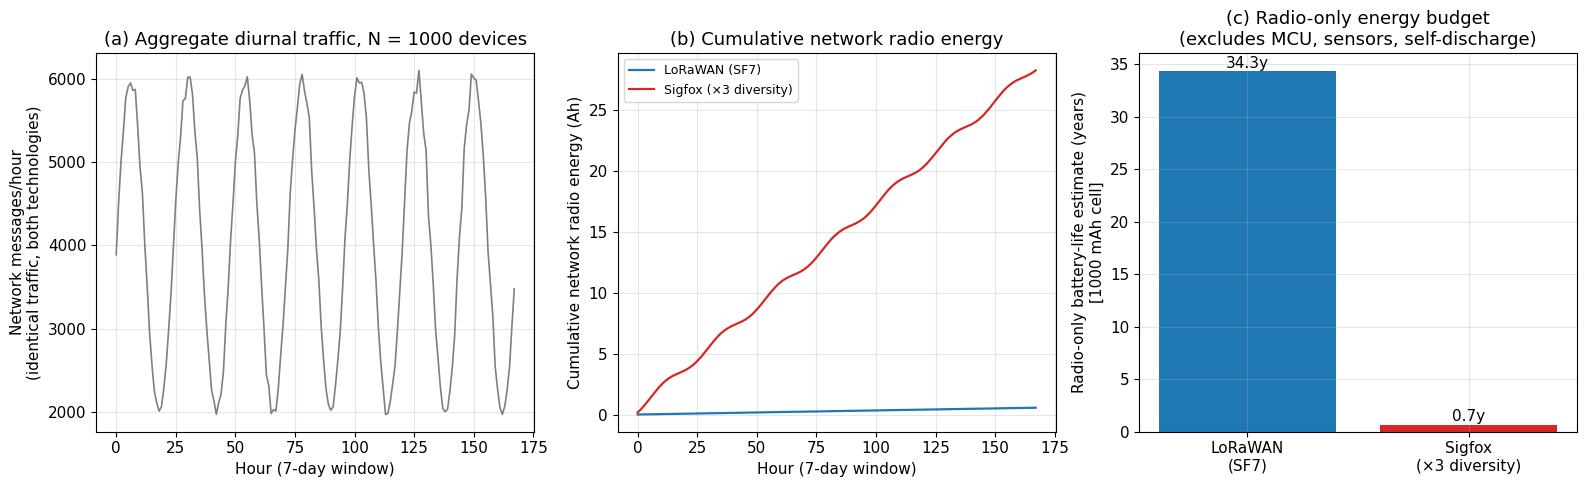

In [10]:
# ── Figure 20.3: traffic, cumulative energy, RADIO-ONLY battery life ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(hours, msgs_per_hour, color='gray', lw=1.2)
ax.set_xlabel('Hour (7-day window)')
ax.set_ylabel('Network messages/hour\n(identical traffic, both technologies)')
ax.set_title('(a) Aggregate diurnal traffic, N = 1000 devices')

ax = axes[1]
ax.plot(hours, np.cumsum(lora_energy_hourly)/1000, color='tab:blue', label='LoRaWAN (SF7)')
ax.plot(hours, np.cumsum(sigfox_energy_hourly)/1000, color='tab:red', label='Sigfox (×3 diversity)')
ax.set_xlabel('Hour (7-day window)'); ax.set_ylabel('Cumulative network radio energy (Ah)')
ax.set_title('(b) Cumulative network radio energy'); ax.legend(fontsize=9)

ax = axes[2]
techs = ['LoRaWAN\n(SF7)', 'Sigfox\n(×3 diversity)']
years = [lora_battery_years, sigfox_battery_years]
bars = ax.bar(techs, years, color=['tab:blue', 'tab:red'])
ax.set_ylabel(f'Radio-only battery-life estimate (years)\n[{BATTERY_MAH:.0f} mAh cell]')
ax.set_title('(c) Radio-only energy budget\n(excludes MCU, sensors, self-discharge)')
for b, y in zip(bars, years):
    ax.text(b.get_x()+b.get_width()/2, y+0.3, f'{y:.1f}y', ha='center')

plt.tight_layout()
plt.show()

In [11]:
# ── Exercise 20.3 output: traffic/energy comparison summary ───────────
print(f"LoRaWAN time-on-air ({LORA_PAYLOAD_BYTES} B, SF{LORA_SF}): {LORA_TOA_S*1000:.1f} ms")
print(f"Sigfox total airtime (3 x {SIGFOX_TOA_SINGLE_S:.1f} s repeats):    {SIGFOX_TOTAL_AIRTIME_S:.1f} s")
print(f"Average messages/device/day (simulated):                {msgs_per_day_per_device.mean():.1f}\n")

print(f"{'Metric':<36s} {'LoRaWAN':>12s} {'Sigfox':>12s}")
print('-'*62)
print(f"{'Mean network throughput (bps)':<36s} {lora_throughput_bps.mean():12.1f} {sigfox_throughput_bps.mean():12.2f}")
print(f"{'Mean network radio energy (mAh/hr)':<36s} {lora_energy_hourly.mean():12.3f} {sigfox_energy_hourly.mean():12.3f}")
print(f"{'Per-device radio energy (mAh/day)':<36s} {lora_mAh_per_day_device.mean():12.5f} {sigfox_mAh_per_day_device.mean():12.5f}")
print(f"{'RADIO-ONLY battery-life est. (yr)':<36s} {lora_battery_years:12.1f} {sigfox_battery_years:12.1f}")

print(f"\nThroughput ratio  (LoRaWAN / Sigfox): {lora_throughput_bps.mean()/sigfox_throughput_bps.mean():.1f}x")
print(f"Energy ratio      (Sigfox / LoRaWAN):  {sigfox_energy_hourly.mean()/lora_energy_hourly.mean():.1f}x")

max_lora_per_hour_dc = 3600*0.01/LORA_TOA_S
print(f"\nLoRaWAN duty-cycle ceiling: {max_lora_per_hour_dc:.0f} msgs/hr/device "
      f"(simulated mean = {BASE_MSGS_PER_HOUR_PER_DEVICE} msgs/hr/device -> ample headroom)")
print(f"Sigfox regulatory ceiling:  {SIGFOX_MAX_UPLINK_PER_DAY} msgs/day/device "
      f"(simulated mean = {msgs_per_day_per_device.mean():.1f} msgs/day/device -> nearly saturated)")
print("\nReminder: battery-life figures above are a RADIO-ONLY upper bound, not a")
print("field-deployable lifetime guarantee -- see the scope note above.")

LoRaWAN time-on-air (20 B, SF7): 56.6 ms
Sigfox total airtime (3 x 2.0 s repeats):    6.0 s
Average messages/device/day (simulated):                96.1

Metric                                    LoRaWAN       Sigfox
--------------------------------------------------------------
Mean network throughput (bps)               177.9       106.76
Mean network radio energy (mAh/hr)          3.325      168.319
Per-device radio energy (mAh/day)         0.07979      4.03965
RADIO-ONLY battery-life est. (yr)            34.3          0.7

Throughput ratio  (LoRaWAN / Sigfox): 1.7x
Energy ratio      (Sigfox / LoRaWAN):  50.6x

LoRaWAN duty-cycle ceiling: 636 msgs/hr/device (simulated mean = 4.0 msgs/hr/device -> ample headroom)
Sigfox regulatory ceiling:  140 msgs/day/device (simulated mean = 96.1 msgs/day/device -> nearly saturated)

Reminder: battery-life figures above are a RADIO-ONLY upper bound, not a
field-deployable lifetime guarantee -- see the scope note above.


In [12]:
# ── Sensitivity check: more typical (sparser) Sigfox reporting cadence ─
for msgs_day in [12, 24, 96]:
    lora_mah = msgs_day*LORA_TOA_S*LORA_TX_CURRENT_MA/3600 + LORA_SLEEP_CURRENT_MA*24
    sig_mah  = msgs_day*SIGFOX_TOTAL_AIRTIME_S*SIGFOX_TX_CURRENT_MA/3600 + SIGFOX_SLEEP_CURRENT_MA*24
    print(f"msgs/day = {msgs_day:3d}   LoRaWAN: {lora_mah:.5f} mAh/day "
          f"({BATTERY_MAH/lora_mah/365:5.1f} y)   "
          f"Sigfox: {sig_mah:.5f} mAh/day ({BATTERY_MAH/sig_mah/365:5.1f} y)   "
          f"ratio = {sig_mah/lora_mah:5.1f}x")

msgs/day =  12   LoRaWAN: 0.04147 mAh/day ( 66.1 y)   Sigfox: 0.53600 mAh/day (  5.1 y)   ratio =  12.9x
msgs/day =  24   LoRaWAN: 0.04694 mAh/day ( 58.4 y)   Sigfox: 1.03600 mAh/day (  2.6 y)   ratio =  22.1x
msgs/day =  96   LoRaWAN: 0.07975 mAh/day ( 34.4 y)   Sigfox: 4.03600 mAh/day (  0.7 y)   ratio =  50.6x


### Analysis

**Figure 20.3** and the table above tell a more nuanced story than the
common "Sigfox = ultra-low-power" narrative suggests. At the smart-metering
cadence simulated here (≈96 messages/day per device), Sigfox consumes
roughly **50x** more radio energy per device-hour than LoRaWAN at SF7. The
reason is entirely in the time-on-air, not the transmit current (29 mA vs.
25 mA — nearly identical): a Sigfox message occupies the radio for 6.0 s
(three repetitions at 100 bps), while a 20-byte LoRaWAN packet at SF7 takes
only 56.6 ms — a **106x** difference in raw airtime that swamps everything
else in the energy budget.

> **Radio-only, not field-deployable.** The battery-life numbers above
> (34.3 years LoRaWAN, 0.7 years Sigfox) come from a *radio-only* energy
> model. The 34.3-year figure means "the radio itself is not the limiting
> factor at this traffic rate" — it is **not** a literal claim that a real
> device will run for 34 years. MCU current, sensor sampling, voltage
> regulators, self-discharge, and aging will all dominate well before that.

The sensitivity check above adds an important caveat on the traffic side:
96 messages/day is close to *saturating* Sigfox's 140-message regulatory
ceiling, which is not the regime Sigfox was designed for. At a more typical
Sigfox cadence — a dozen or two messages per day — the energy gap narrows
to roughly 13–22x, and the resulting radio-only battery-life estimate
(several years on a 1000 mAh cell) is much closer to Sigfox's marketed
device lifetimes. Sigfox's real efficiency advantage comes from the
*regulatory and protocol design that strongly discourages frequent
reporting*, not from a fundamentally cheaper radio link.

> **Key takeaway.** "Low power" in LPWAN is a property of how a technology
> is *used*, not only of its physical layer. Sigfox's energy efficiency is
> real but conditional on the very low reporting rates its protocol
> enforces; pushed toward higher message rates, its mandatory triple
> transmission at 100 bps becomes a serious radio-energy liability compared
> to LoRaWAN at an adapted spreading factor. And remember: these are
> radio-only estimates, not deployment guarantees.

### Challenge tasks

1. This simulation does not model collisions, gateway demodulator limits,
   or multi-channel reception. Sketch (or implement, with a simple
   slotted-ALOHA approximation) how packet loss would grow with $N$, and
   identify where collision-driven loss — not airtime budget — becomes the
   binding constraint.
2. Quantify the energy specifically attributable to Sigfox's mandatory
   $\times 3$ repetition (compare against a hypothetical single-transmission
   variant), and connect the result to the reliability gain quantified in
   Exercise 20.4.
3. Replace the smooth diurnal traffic model with a heavy-tailed alarm
   model (rare bursts rather than smooth periodic readings) and re-examine
   how much duty-cycle headroom each technology retains.
4. NB-IoT's 3GPP design target is roughly **10 years on a 5 Wh battery**
   for one low-rate message per day, with PSM idle current below 3 µA
   (3GPP TR 45.820; Sultania et al., 2018). Add a third bar to a copy of
   the Figure 20.3(c) chart for an illustrative NB-IoT device at the same
   message rate, and discuss why a licensed, base-station-scheduled
   technology can reach a different energy/latency trade-off than the
   unlicensed, device-initiated model used here.

---
## Exercise 20.4 — Message Reliability via Frequency Diversity

### Background

Sigfox has no acknowledgement mechanism: a device transmits and moves on
("fire and forget"), with reliability provided entirely by **frequency
diversity** — sending the same message three times on three
pseudo-randomly chosen frequencies. If a single transmission is lost with
probability $p$ (due to interference, fading, or collision with another
device on the shared ISM band) and the three repetitions experience
*independent* losses, the probability that at least one of $k$ copies is
received is:

$$
P_{\text{success}}(k) = 1 - p^{k}
$$

This exercise validates that formula with a direct Monte Carlo simulation,
and then quantifies the cost side of the trade-off: each extra repetition
costs $k\times$ the airtime and energy of a single transmission (the same
quantity that drove the Sigfox energy results in Exercise 20.3). Comparing
the *reliability gain* against the *airtime cost* explains, quantitatively,
why Sigfox standardised on $k=3$ rather than a larger number.

> **Model parameters.** Loss-probability grid $p \in [0.02, 0.60]$ ·
> representative values $p=0.1$ (moderate) and $p=0.3$ (high interference) ·
> repetitions $k \in \{1,2,3,4\}$ (Sigfox uses $k=3$) · 40,000–200,000 Monte
> Carlo trials per point · independent (i.i.d.) losses assumed across
> repetitions (revisited in Challenge Task 1).

In [13]:
# ── Exercise 20.4: frequency-diversity reliability ────────────────────
rng = np.random.default_rng(99)

def monte_carlo_delivery(p_loss, k, n_trials=200000, rng=rng):
    '''P(at least one of k independent transmissions is received).'''
    losses = rng.random((n_trials, k)) < p_loss
    all_lost = losses.all(axis=1)
    return 1 - all_lost.mean()

p_loss_grid = np.linspace(0.02, 0.6, 25)
ks = [1, 2, 3, 4]

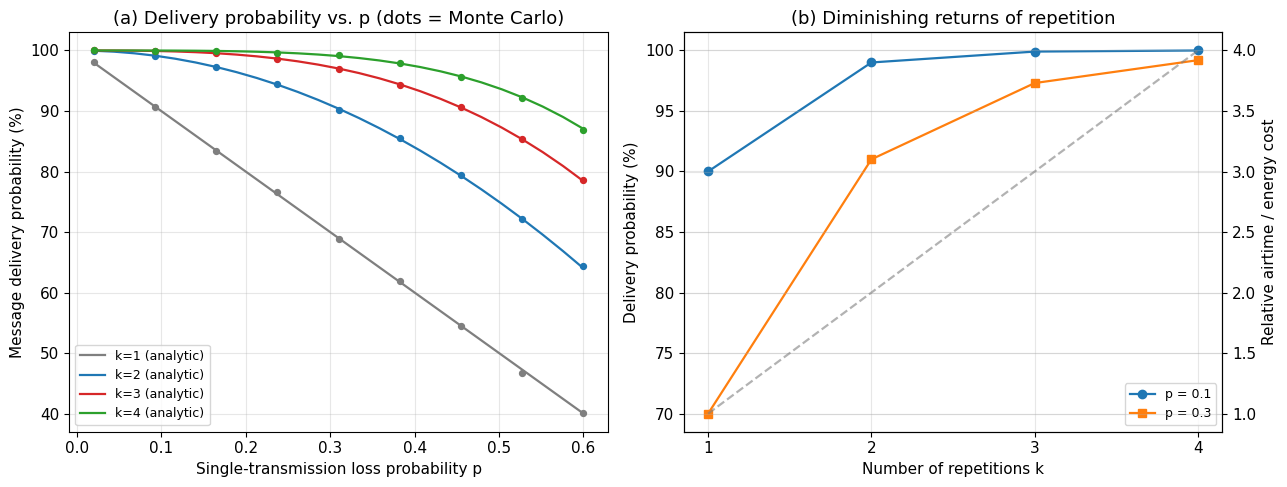

In [14]:
# ── Figure 20.4: delivery probability and diminishing returns ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {1: 'tab:gray', 2: 'tab:blue', 3: 'tab:red', 4: 'tab:green'}

ax = axes[0]
for k in ks:
    sim = [monte_carlo_delivery(p, k, n_trials=40000) for p in p_loss_grid]
    analytic = 1 - p_loss_grid**k
    ax.plot(p_loss_grid, analytic*100, color=colors[k], label=f'k={k} (analytic)')
    ax.scatter(p_loss_grid[::3], np.array(sim)[::3]*100, color=colors[k], s=18, zorder=5)
ax.set_xlabel('Single-transmission loss probability p')
ax.set_ylabel('Message delivery probability (%)')
ax.set_title('(a) Delivery probability vs. p (dots = Monte Carlo)')
ax.legend(fontsize=9)

ax = axes[1]
for p, marker in [(0.1, 'o'), (0.3, 's')]:
    deliv = [1 - p**k for k in ks]
    ax.plot(ks, np.array(deliv)*100, marker=marker, label=f'p = {p}')
ax2 = ax.twinx()
ax2.plot(ks, ks, color='gray', ls='--', alpha=0.6, label='Airtime/energy cost (×k)')
ax.set_xlabel('Number of repetitions k')
ax.set_ylabel('Delivery probability (%)')
ax2.set_ylabel('Relative airtime / energy cost')
ax.set_title('(b) Diminishing returns of repetition')
ax.set_xticks(ks); ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# ── Exercise 20.4 output: delivery probability and airtime cost vs. k ─
for p in [0.1, 0.3]:
    print(f"p_loss = {p}")
    for k in ks:
        analytic = 1 - p**k
        sim = monte_carlo_delivery(p, k, n_trials=200000)
        print(f"  k={k}: P_success(analytic) = {analytic*100:6.3f}%   "
              f"P_success(Monte Carlo) = {sim*100:6.3f}%   airtime cost = {k}x")
    print()

for p in [0.1, 0.3]:
    gain_1_to_3 = (1-p**3) - (1-p**1)
    gain_3_to_4 = (1-p**4) - (1-p**3)
    print(f"p={p}: gain(k=1->3) = {gain_1_to_3*100:.3f} pp for +2x cost   |   "
          f"gain(k=3->4) = {gain_3_to_4*100:.4f} pp for +1x cost")

p_loss = 0.1
  k=1: P_success(analytic) = 90.000%   P_success(Monte Carlo) = 90.097%   airtime cost = 1x
  k=2: P_success(analytic) = 99.000%   P_success(Monte Carlo) = 99.031%   airtime cost = 2x
  k=3: P_success(analytic) = 99.900%   P_success(Monte Carlo) = 99.918%   airtime cost = 3x
  k=4: P_success(analytic) = 99.990%   P_success(Monte Carlo) = 99.989%   airtime cost = 4x

p_loss = 0.3
  k=1: P_success(analytic) = 70.000%   P_success(Monte Carlo) = 69.739%   airtime cost = 1x
  k=2: P_success(analytic) = 91.000%   P_success(Monte Carlo) = 90.983%   airtime cost = 2x
  k=3: P_success(analytic) = 97.300%   P_success(Monte Carlo) = 97.363%   airtime cost = 3x
  k=4: P_success(analytic) = 99.190%   P_success(Monte Carlo) = 99.199%   airtime cost = 4x

p=0.1: gain(k=1->3) = 9.900 pp for +2x cost   |   gain(k=3->4) = 0.0900 pp for +1x cost
p=0.3: gain(k=1->3) = 27.300 pp for +2x cost   |   gain(k=3->4) = 1.8900 pp for +1x cost


### Analysis

**Figure 20.4(a)** confirms that the Monte Carlo simulation tracks the
closed-form $1-p^k$ expression essentially exactly, across the full range
of loss probabilities and all four values of $k$ tested — exactly what we
expect when transmissions really are independent.

**Figure 20.4(b)** and the table above show why $k=3$ is a well-chosen
design point rather than an arbitrary one. At a moderate interference level
($p=0.1$), a single transmission already succeeds 90% of the time; two
repetitions push that to 99%; three repetitions reach 99.9% ("three nines")
— a gain of 9.9 percentage points for twice the airtime. Adding a fourth
repetition buys only another 0.09 percentage points for yet another unit of
airtime cost: the marginal return has all but vanished. At a more hostile
interference level ($p=0.3$), the pattern is the same but the numbers are
larger in absolute terms (a 27.3-percentage-point gain from $k=1$ to
$k=3$), reflecting how diversity schemes matter most precisely when the
channel is unreliable, which is exactly the situation Sigfox engineered for.

These results connect directly to the energy analysis in Exercise 20.3:
the $\times 3$ repetition that drove Sigfox's higher energy cost there is
the same mechanism delivering its strong reliability guarantee here. There
is no way to get the reliability benefit without paying the energy cost in
this fire-and-forget design — the two are the same trade-off viewed from
different angles.

> **Key takeaway.** With independent per-transmission loss probability
> $p$, sending $k$ copies improves delivery probability from $1-p$ to
> $1-p^k$ at a strictly linear airtime/energy cost of $k\times$. Returns
> diminish quickly: for realistic interference levels, $k=3$ already
> captures the great majority of the achievable improvement, which is
> almost certainly why Sigfox settled on triple transmission rather than,
> say, five or ten repetitions.

### Challenge tasks

1. Replace the independence assumption with a simple two-state (good/bad)
   Markov channel model that produces *correlated* losses across the
   three frequency-hopped repetitions, and assess how much the diversity
   gain shrinks when losses are bursty rather than independent.
2. LoRaWAN has no automatic uplink diversity at the application layer.
   Design an equivalent $k$-copy diversity scheme for a LoRaWAN uplink,
   using the time-on-air function from Exercise 20.2 to compute its
   airtime cost, and compare it to Sigfox's.
3. Using the energy model from Exercise 20.3, compute the daily energy
   cost of guaranteeing 99.9% delivery via $k=3$ Sigfox diversity, versus
   a single LoRaWAN Class A confirmed uplink with one ARQ retransmission
   on failure. Which is more energy-efficient for a 99.9% reliability
   target?
4. Model $p$ itself as a function of network load (e.g., a simple ALOHA
   collision probability that grows with the number of devices $N$
   sharing the band) and produce a combined network-load-and-diversity
   reliability curve.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 20.1 | Hata (Okumura-Hata) path loss + log-normal shadowing | Realistic, probability-based coverage planning instead of an optimistic single-number range |
| 20.2 | LoRa time-on-air and data-rate model | Quantifies the range/throughput/capacity trade-off that motivates Adaptive Data Rate |
| 20.3 | Duty-cycle traffic and energy simulation | Battery-life and network-capacity estimates for technology selection |
| 20.4 | Monte Carlo validation of frequency diversity | Explains, quantitatively, the reliability/airtime trade-off behind Sigfox's "fire-and-forget" design |

All four exercises build on the same small set of physical-layer
primitives — a path-loss/shadowing model and a time-on-air model — which is
itself a useful lesson: a handful of well-validated formulas, reused
consistently, go a long way toward turning marketing-style LPWAN
comparisons ("long range, low power") into concrete, defensible engineering
numbers. The next sections of this chapter turn to the real-world
deployments (Section 20.4) where these exact trade-offs are made in
practice.